In [140]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
annual_value_adjusted = pd.read_csv("data/outputs/annual_ca_port",
                                    index_col =0, parse_dates = [1])
quarterly_value_adjusted = pd.read_csv('data/outputs/quarter_ca_port',
                                    index_col =0, parse_dates = [1])
band_value_adjusted = pd.read_csv("data/outputs/quarter_band_ca_port",
                                    index_col =0, parse_dates = [1])
asset_data = pd.read_csv("data/processed/daily_returns.csv",
                         parse_dates = [0])


In [ ]:
annual_weights = pd.read_csv("data/outputs/annually_rebalanced_weights", 
                             index_col = 0, parse_dates = [1])
quarterly_weights = pd.read_csv("data/outputs/quarterly_rebalanced_weights", 
                                index_col = 0, parse_dates = [1])
band_weights = pd.read_csv("data/outputs/quarterly_rebalanced_byband_weights", 
                           index_col = 0, parse_dates = [1])

In [ ]:
spy = asset_data[['Date','SPY']]
spy_data = spy[spy['Date'].isin(annual_value_adjusted['Date'])]

In [ ]:
def weighted_beta_calculation(weights_df, values_df, benchmark):
    
    beta_list = []

    starting_weights = weights_df[weights_df['weight_type'] == 'starting']

    start_dates = weights_df.loc[weights_df['weight_type'] == 'starting', 'Date']

    end_dates = weights_df.loc[weights_df['weight_type'] == 'ending', 'Date']

    for row in range(len(start_dates)):

        beta_series = pd.Series(index = values_df.columns, dtype = float).drop('Date')
        
        start = start_dates.iloc[row]
        
        end = end_dates.iloc[row]

        period_data = values_df[values_df['Date'].between(start, end)].drop(columns = 'Date')

        benchmark_var = values_df.loc[values_df['Date'].between(start, end), benchmark].var()

        for col in period_data.columns:
            cov = period_data[col].cov(period_data[benchmark])
            beta = cov / benchmark_var
            beta_series[col] = beta

        weights = starting_weights[starting_weights['Date'] == start].drop(columns = ['Date','weight_type'])
        weight_betas = weights.iloc[0] * beta_series
        period_beta = sum(weight_betas)

        beta_list.append({
            'start' : start,
            'end' : end,
            'beta': period_beta
        })



    return pd.DataFrame(beta_list), weight_betas


In [152]:

annual_weighted_beta_df, annual_asset_betas = weighted_beta_calculation(annual_weights, asset_data, "SPY")
quarter_weighted_beta_df, quarterly_asset_betas = weighted_beta_calculation(quarterly_weights, asset_data, "SPY")
band_weighted_beta_df, banded_asset_betas = weighted_beta_calculation(band_weights, asset_data, "SPY")
    

In [153]:
banded_asset_betas

AGG     3.959275e-02
EEM     4.213384e-01
EFA     1.775235e-16
GLD     1.412044e-01
IWM     1.367786e-01
LQD     4.428072e-02
MTUM    1.300286e-01
QQQ     2.135553e-01
QUAL    7.851442e-03
SPY     6.418477e-16
TLT     2.039878e-16
USMV   -0.000000e+00
VLUE    2.863647e-01
VNQ    -0.000000e+00
dtype: float64

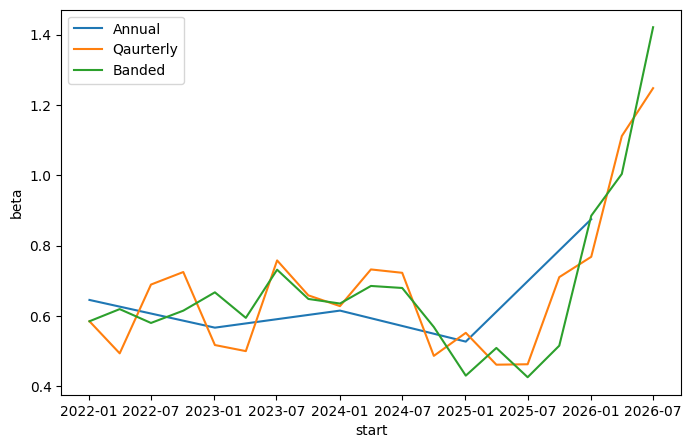

In [145]:
plt.figure(figsize = (8,5))
sns.lineplot(data = annual_weighted_beta_df, x = 'start', y = 'beta', label = 'Annual')
sns.lineplot(data = quarter_weighted_beta_df, x = 'start', y = 'beta', label = 'Qaurterly')
sns.lineplot(data = band_weighted_beta_df, x = 'start', y = 'beta', label = 'Banded')
plt.legend()

In [4]:
from src.metrics import portfolio_beta

In [ ]:
portfolio_beta(
    portfolio_return = annual_value_adjusted['portfolio_return'],
    benchmark_return = spy_data['SPY']
    )

np.float64(0.0072619514109706984)

In [6]:
asset_data

,Date,AGG,EEM,EFA,GLD,IWM,LQD,MTUM,QQQ,QUAL,SPY,TLT,USMV,VLUE,VNQ
0,2021-07-13,-0.002163,0.000933,-0.005257,0.001302,-0.018846,-0.003711,-0.010302,0.000000,-0.001842,-0.003409,-0.007653,-0.002133,-0.009707,-0.013968
1,2021-07-14,0.003381,0.004287,0.002265,0.010755,-0.015430,0.004618,-0.007287,0.001794,0.000960,0.001492,0.011362,0.003607,-0.000288,0.006987
2,2021-07-15,0.002160,0.002413,-0.009540,0.000175,-0.005665,0.002150,-0.002330,-0.007024,-0.003763,-0.003416,0.011030,0.000932,-0.004518,0.001616
3,2021-07-16,-0.000862,-0.007776,-0.007351,-0.009704,-0.012314,-0.001406,-0.011153,-0.008099,-0.005628,-0.007844,-0.001885,0.001198,-0.012553,-0.000664
4,2021-07-19,0.005263,-0.016794,-0.018131,0.001181,-0.014980,0.007187,-0.013758,-0.008193,-0.012733,-0.014768,0.021928,-0.009299,-0.016526,-0.018232
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1249,2026-07-06,0.000507,0.028463,0.010444,0.010578,0.004436,0.000276,0.016365,0.014342,0.000275,0.008727,-0.000702,0.000000,0.005338,-0.007958
1250,2026-07-07,-0.004561,-0.027379,-0.012327,-0.012143,-0.009067,-0.007270,-0.028815,-0.018525,-0.003433,-0.004752,-0.010532,0.004699,-0.010979,0.011929
1251,2026-07-08,-0.001731,0.007760,-0.007681,-0.008053,-0.009150,-0.001947,0.007713,0.002833,-0.003766,-0.003089,-0.002247,-0.007117,-0.002137,-0.016260
1252,2026-07-09,0.001428,0.008304,0.005418,0.009961,0.012812,0.000372,0.020168,0.016642,0.007284,0.008465,0.001541,-0.000512,0.019012,0.002996


CAPM
Jensen Alpha
Treynor
Information Ratio
Tracking Error
Rolling Beta